# Chapter 03. Inside the Transformer: What There Is to Explain

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammadi-hadi/hands-on-xai-labs/blob/main/notebooks/ch03-inside-the-transformer.ipynb)

Companion notebook for Chapter 03 of *Hands-On Explainable AI*.

**What you'll build:** a guided dissection of GPT-2 small using nothing but the `transformers` library. You'll push one tricky sentence through three tokenizers and see why subwords sabotage word-level attributions, measure the geometry (and anisotropy) of the input-embedding space, read one attention head honestly, build a logit lens from scratch to watch the prediction "Amsterdam" assemble itself layer by layer (and then watch the final layer overrule it), and finish with a map of every artifact a transformer exposes and which chapter of this book taps it.

In [1]:
%%capture
import importlib.util
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    %pip install -q transformers==4.57.6 numpy==1.26.4 pandas==3.0.3 matplotlib==3.11.1

In [2]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Smoke mode: CI sets BOOK_SMOKE=1 to swap in tiny models + tiny data
SMOKE = os.environ.get("BOOK_SMOKE") == "1"
DEVICE = os.environ.get("BOOK_DEVICE") or (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

_style = Path("../styles/book.mplstyle")
if _style.exists():
    plt.style.use(_style)
INK, RUST, TEAL, AMBER, ROSE, STONE = "#1A1C1E", "#9A3412", "#0D9488", "#F59E0B", "#E11D48", "#A8A29E"
GRAPHITE = "#57534E"  # secondary text

print(f"device={DEVICE} smoke={SMOKE}")

device=cpu smoke=False


## 1. Tokens: the units every explanation is built on

Every attribution method in Part II hands back one score *per token*. So before we can explain anything, we need to know what a token actually is, because it is almost never a word. We push one deliberately awkward sentence (a rare word, a typo, an emoji) through three tokenizers: GPT-2's byte-level BPE, BERT's WordPiece, and Qwen2.5's modern BPE.

In [3]:
from transformers import AutoTokenizer

SENT = "The unexplainability of LLMs isn't obvsly a solved problem \U0001F914"

TOKENIZER_SPECS = [
    ("GPT-2 (byte-level BPE)", "gpt2"),
    ("BERT (WordPiece)", "bert-base-uncased"),
    ("Qwen2.5 (modern BPE)", "Qwen/Qwen2.5-0.5B-Instruct"),
]

tokenizations = []
for label, name in TOKENIZER_SPECS:
    tk = AutoTokenizer.from_pretrained(name)
    enc = tk(SENT, add_special_tokens=False, return_offsets_mapping=True)
    toks = tk.convert_ids_to_tokens(enc["input_ids"])
    tokenizations.append({"label": label, "tokens": toks, "offsets": enc["offset_mapping"]})
    print(f"{label:24s} {len(toks):2d} tokens: {toks}")

# the word every explanation will have to score:
span = (SENT.index("unexplainability"), SENT.index("unexplainability") + len("unexplainability"))
for t in tokenizations:
    pieces = [tok for tok, (a, b) in zip(t["tokens"], t["offsets"]) if a < span[1] and b > span[0]]
    print(f'{t["label"]:24s} splits "unexplainability" into {len(pieces)}: {pieces}')

GPT-2 (byte-level BPE)   18 tokens: ['The', 'Ġunex', 'plain', 'ability', 'Ġof', 'ĠLL', 'Ms', 'Ġisn', "'t", 'Ġob', 'vs', 'ly', 'Ġa', 'Ġsolved', 'Ġproblem', 'ĠðŁ', '¤', 'Ķ']


BERT (WordPiece)         19 tokens: ['the', 'une', '##x', '##pl', '##aina', '##bility', 'of', 'll', '##ms', 'isn', "'", 't', 'ob', '##vs', '##ly', 'a', 'solved', 'problem', '[UNK]']


Qwen2.5 (modern BPE)     19 tokens: ['The', 'Ġun', 'explain', 'ability', 'Ġof', 'ĠL', 'LM', 's', 'Ġisn', "'t", 'Ġob', 'vs', 'ly', 'Ġa', 'Ġsolved', 'Ġproblem', 'ĠðŁ', '¤', 'Ķ']
GPT-2 (byte-level BPE)   splits "unexplainability" into 3: ['Ġunex', 'plain', 'ability']
BERT (WordPiece)         splits "unexplainability" into 5: ['une', '##x', '##pl', '##aina', '##bility']
Qwen2.5 (modern BPE)     splits "unexplainability" into 3: ['Ġun', 'explain', 'ability']


Three tokenizers, three different segmentations, and *none* of the pieces is the word "unexplainability". GPT-2 finds `plain` inside it, Qwen finds `explain`, BERT shatters it into five shards. Any "word importance" number you ever report is therefore an *aggregation choice* (sum? max? mean over pieces?) layered on top of the model's real units. Chapter 4 measures how much that choice alone changes attributions. The emoji survives only as three raw byte tokens in the BPE vocabularies, and BERT drops it to `[UNK]` entirely: whatever the model does with that emoji, a WordPiece explanation cannot see it.

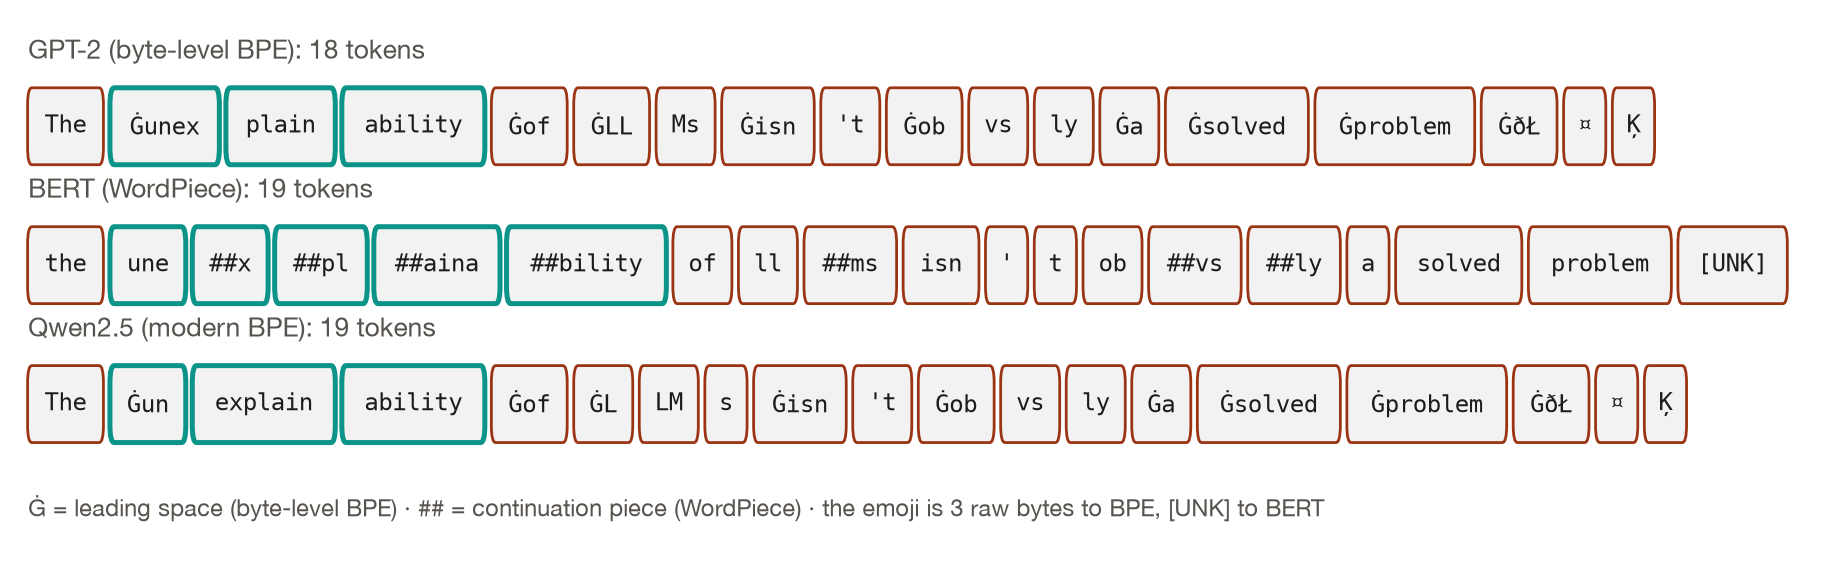

In [4]:
#| label: fig-token-granularity
#| fig-cap: "One sentence, three tokenizers: the rare word splits into 3-5 disagreeing subword pieces (teal outlines); the emoji survives only as raw bytes. Word-level attribution is an aggregation choice, not a given."
#| fig-alt: "Three rows of token boxes for the same sentence under three tokenizers: the rare word splits into three to five differing subword pieces and the emoji becomes raw byte tokens."
from matplotlib.colors import to_rgba
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11.5, 3.4))
row_y = [2.6, 1.3, 0.0]
max_x = 0.0
for (y, t) in zip(row_y, tokenizations):
    x = 0.0
    for tok_str, (a, b) in zip(t["tokens"], t["offsets"]):
        w = max(len(tok_str), 1) * 0.62 + 0.9
        in_word = a < span[1] and b > span[0]
        ax.add_patch(FancyBboxPatch(
            (x, y - 0.34), w, 0.68,
            boxstyle="round,pad=0.02,rounding_size=0.16",
            facecolor=to_rgba(STONE, 0.13),
            edgecolor=TEAL if in_word else RUST,
            linewidth=1.8 if in_word else 1.0, zorder=3))
        ax.text(x + w / 2, y, tok_str, ha="center", va="center",
                fontsize=8.5, family="monospace", color=INK, zorder=4)
        x += w + 0.28
    max_x = max(max_x, x)
    ax.text(0, y + 0.58, f'{t["label"]}: {len(t["tokens"])} tokens',
            fontsize=9.5, color=GRAPHITE, va="bottom")
ax.text(0, -1.05, "\u0120 = leading space (byte-level BPE) \u00b7 ## = continuation piece (WordPiece)"
        " \u00b7 the emoji is 3 raw bytes to BPE, [UNK] to BERT",
        fontsize=8.5, color=GRAPHITE)
ax.set_xlim(-0.3, max_x + 0.3)
ax.set_ylim(-1.3, 3.6)
ax.axis("off")
plt.show()

## 2. Embedding geometry: where meaning starts

The first thing a transformer does with a token id is look up a row of a learned matrix: for GPT-2 small, one of 50,257 vectors with 768 dimensions. This matrix is a *weight*: readable offline, no forward pass required, our first explanation artifact. Cosine neighbors tell us what the model considers similar before any context arrives. We also measure **anisotropy** (how far the space is from "random directions are orthogonal") because it decides how much a given cosine similarity is actually worth.

In [5]:
from transformers import AutoModelForCausalLM

tok = AutoTokenizer.from_pretrained("gpt2")
# eager attention so the model returns per-head attention weights (section 3)
model = AutoModelForCausalLM.from_pretrained("gpt2", attn_implementation="eager")
model.eval()

E = model.transformer.wte.weight.detach()          # (50257, 768) input embeddings
E_unit = E / E.norm(dim=-1, keepdim=True)

PROBE_WORDS = [" king"] if SMOKE else [" king", " Amsterdam", " happy", " explain"]

def top_neighbors(word, k=8):
    wid = tok(word)["input_ids"]
    assert len(wid) == 1, f"{word!r} is not a single token"
    sims = E_unit @ E_unit[wid[0]]
    top = torch.topk(sims, k + 1)                  # +1: the word itself comes back first
    return [f"{tok.decode([i])!r} ({s:.3f})" for i, s in zip(top.indices[1:], top.values[1:])]

if SMOKE:
    print("smoke mode: 1 probe word, no table")
    print(PROBE_WORDS[0], "->", top_neighbors(PROBE_WORDS[0], k=3))
else:
    table = pd.DataFrame({w.strip(): top_neighbors(w) for w in PROBE_WORDS},
                         index=[f"#{i}" for i in range(1, 9)])
    display(table)

# anisotropy: mean pairwise cosine of random token embeddings (isotropic space -> ~0)
N = 200 if SMOKE else 1000
idx = np.random.default_rng(SEED).choice(E.shape[0], N, replace=False)
S = E_unit[idx] @ E_unit[idx].T
aniso = float((S.sum() - N) / (N * (N - 1)))
print(f"\nanisotropy: mean pairwise cosine of {N} random token embeddings = {aniso:.3f}")

,king,Amsterdam,happy,explain
#1,' kings' (0.733),' Netherlands' (0.657),'happy' (0.696),' explains' (0.740)
#2,' King' (0.696),' Dutch' (0.644),' Happy' (0.687),' explaining' (0.701)
#3,' queen' (0.657),'Dutch' (0.603),' happier' (0.674),' explained' (0.689)
#4,'King' (0.604),'sterdam' (0.588),' unhappy' (0.663),' explanation' (0.684)
#5,' prince' (0.590),' Holland' (0.579),'Happy' (0.658),' Explain' (0.658)
#6,' monarch' (0.581),' Belgium' (0.572),' pleased' (0.628),' explanations' (0.636)
#7,' emperor' (0.557),' Oslo' (0.568),' glad' (0.624),' describe' (0.634)
#8,' ruler' (0.551),' Prague' (0.567),' thrilled' (0.622),' discuss' (0.568)



anisotropy: mean pairwise cosine of 1000 random token embeddings = 0.269


The neighbor lists read like a thesaurus wrote them: ` king` sits next to ` kings`, ` queen`, ` monarch`; ` Amsterdam` next to ` Netherlands`, ` Dutch`, ` Holland` (and, tellingly, ` Oslo` and ` Prague`: "European capital" is a *direction* in this space). But note the anisotropy number: two **random** tokens already have cosine ≈ 0.27, not 0. The embedding space is a narrow cone, not a ball, so a cosine of 0.5 means far less than it would in an isotropic space. Whenever a similarity number appears inside an explanation (concept vectors in Chapter 6, retrieval in Chapter 13), first ask what the baseline similarity of *nothing in common* is.

## 3. One attention head, read honestly

Attention weights are the most photographed artifact in the transformer, so let's set the terms of honest reading early. We feed a sentence with a clear coreference (*it* should point back to *cat*) and inspect **layer 5, all 12 heads**. The question is not "can we find a pretty head?" (we can, and we will) but "what were the other eleven doing?"

In [6]:
# The whole mechanism once, by hand, before any head-level claims: one query
# token, its raw query-key dot products, and the softmax that turns those
# scores into mixing weights. Layer 5, head 10, on the sentence analyzed next.
MICRO_SENT = "When the cat jumped onto the table, it knocked over a glass."
enc_m = tok(MICRO_SENT, return_tensors="pt")
toks_m = tok.convert_ids_to_tokens(enc_m["input_ids"][0])

L_M, H_M, D_HEAD = 5, 10, 64
with torch.no_grad():
    hs_m = model(**enc_m, output_hidden_states=True).hidden_states
    x_m = model.transformer.h[L_M].ln_1(hs_m[L_M])       # what block 5's attention sees
    q_m, k_m, _ = model.transformer.h[L_M].attn.c_attn(x_m).split(768, dim=-1)
    q_m = q_m.view(1, -1, 12, D_HEAD)[0, :, H_M]         # head 10's queries (seq, 64)
    k_m = k_m.view(1, -1, 12, D_HEAD)[0, :, H_M]         # head 10's keys    (seq, 64)

qi_m = toks_m.index("\u0120it")
scores_m = (q_m[qi_m] @ k_m.T) / D_HEAD**0.5             # one raw q.k score per key
weights_m = torch.softmax(scores_m[: qi_m + 1], dim=-1)  # causal: only visible keys

CANDS = ["\u0120cat", "\u0120jumped", "When", "\u0120table"]
shown = [toks_m.index(c) for c in CANDS]
print(f"query = {tok.convert_tokens_to_string([toks_m[qi_m]])!r}   layer {L_M}, head {H_M}")
print(f"{'key':<14}{'q.k/sqrt(64)':>13}{'softmax weight':>17}")
for j in shown:
    key = tok.convert_tokens_to_string([toks_m[j]])
    print(f"{key!r:<14}{float(scores_m[j]):>13.2f}{float(weights_m[j]):>17.3f}")
rest = float(weights_m.sum() - weights_m[shown].sum())
print(f"{'(5 other keys)':<14}{'':>13}{rest:>17.3f}")
print(f"weights sum to {float(weights_m.sum()):.3f}")

query = ' it'   layer 5, head 10
key            q.k/sqrt(64)   softmax weight
' cat'                 3.37            0.448
' jumped'              2.79            0.252
'When'                 2.15            0.133
' table'              -0.88            0.006
(5 other keys)                         0.161
weights sum to 1.000


In [7]:
COREF_SENT = "When the cat jumped onto the table, it knocked over a glass."
enc_c = tok(COREF_SENT, return_tensors="pt")
coref_tokens = tok.convert_ids_to_tokens(enc_c["input_ids"][0])
with torch.no_grad():
    out_c = model(**enc_c, output_attentions=True)
ATT = torch.stack(out_c.attentions).squeeze(1)     # (layer, head, query, key)

it_pos = coref_tokens.index("\u0120it")
cat_pos = coref_tokens.index("\u0120cat")

LAYER = 5
rows = []
for h in range(ATT.shape[1]):
    a = ATT[LAYER, h, it_pos]                      # where 'it' looks, head by head
    rows.append({"head": h, "it->cat": round(float(a[cat_pos]), 3),
                 "strongest key": coref_tokens[int(a.argmax())],
                 "weight on first token": round(float(a[0]), 3)})
display(pd.DataFrame(rows).set_index("head"))

BEST_HEAD = int(ATT[LAYER, :, it_pos, cat_pos].argmax())
share_first = float(ATT[LAYER, :, 1:, 0].mean())
print(f"best layer-{LAYER} head for it->cat: head {BEST_HEAD} "
      f"(weight {float(ATT[LAYER, BEST_HEAD, it_pos, cat_pos]):.3f})")
print(f"mean attention that layer-{LAYER} heads park on the FIRST token: {share_first:.2f}")

,it->cat,strongest key,weight on first token
head,,,
0,0.003,When,0.906
1,0.000,When,0.992
2,0.020,When,0.575
3,0.016,When,0.571
4,0.018,When,0.491
5,0.008,When,0.760
6,0.001,When,0.863
7,0.010,When,0.909
8,0.006,Ġjumped,0.365


best layer-5 head for it->cat: head 10 (weight 0.448)
mean attention that layer-5 heads park on the FIRST token: 0.75


**The honest read:** exactly one head (head 10) routes `it` back to `cat`, with weight 0.45. The other eleven point `it` mostly at the *first token* of the sentence. Layer 5 as a whole parks about three quarters of its attention there. That is not the model "thinking about *When*"; it is a well-documented resting position (an attention sink) for heads with nothing to say at this position. Keep both facts in mind whenever a paper shows you one beautiful head: it was selected from hundreds, and the unselected majority look like this. Chapter 5 turns this from an anecdote into a method, and a critique.

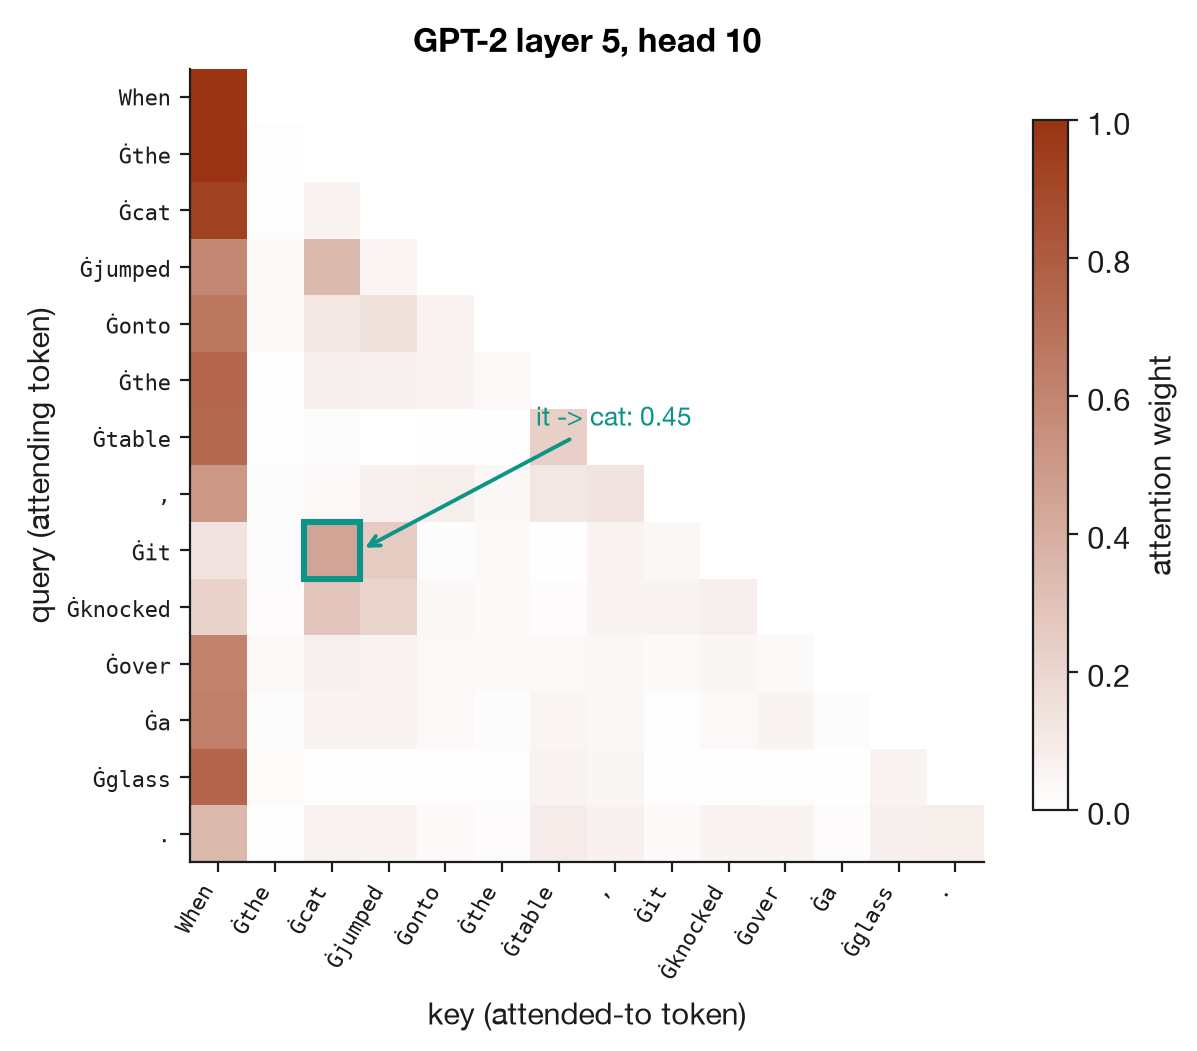

In [8]:
#| label: fig-attention-head
#| fig-cap: "Layer 5, head 10 of GPT-2: the query token 'it' puts weight 0.45 on 'cat' (teal box), the one head in twelve that reads as coreference; blank cells are causally masked future positions."
#| fig-alt: "Attention heatmap for one GPT-2 head: the query token it places weight 0.45 on cat, while most other cells sit near zero."
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

rust_cmap = LinearSegmentedColormap.from_list("rust", ["#FFFFFF", RUST])
A = ATT[LAYER, BEST_HEAD].numpy().copy()
A[np.triu_indices_from(A, k=1)] = np.nan           # causal mask: future keys don't exist

fig, ax = plt.subplots(figsize=(6.4, 5.6))
im = ax.imshow(A, cmap=rust_cmap, vmin=0, vmax=1)
ax.set_xticks(range(len(coref_tokens)))
ax.set_xticklabels(coref_tokens, rotation=60, ha="right", fontsize=8, family="monospace")
ax.set_yticks(range(len(coref_tokens)))
ax.set_yticklabels(coref_tokens, fontsize=8, family="monospace")
ax.set_xlabel("key (attended-to token)")
ax.set_ylabel("query (attending token)")
ax.add_patch(Rectangle((cat_pos - 0.5, it_pos - 0.5), 1, 1, fill=False, edgecolor=TEAL, linewidth=2.2))
ax.annotate(f"it -> cat: {float(ATT[LAYER, BEST_HEAD, it_pos, cat_pos]):.2f}",
            xy=(cat_pos + 0.5, it_pos), xytext=(cat_pos + 3.6, it_pos - 2.2),
            color=TEAL, fontsize=9.5,
            arrowprops={"arrowstyle": "->", "color": TEAL, "linewidth": 1.4})
ax.set_title(f"GPT-2 layer {LAYER}, head {BEST_HEAD}")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="attention weight")
plt.show()

## 4. The logit lens: watching a prediction assemble itself

The residual stream keeps the same width (768) at every layer, and the model's own output head (`ln_f` + `lm_head`) maps any such vector to a distribution over next tokens. So nothing stops us from applying the output head to *every* layer's hidden state and asking: *if the model had to answer now, what would it say?* That trick is the **logit lens** (nostalgebraist, 2020), and it is the most instructive ten lines of code in this book.

One technical line that matters: we must apply the final LayerNorm `ln_f` before unembedding, because `lm_head` was only ever trained to read *normalized* vectors: raw mid-layer states have wildly different scales (section 5 measures this) and produce garbage logits without it. (`transformers` has already applied `ln_f` to the last hidden state, so we leave that one alone, which also makes our last lens row exactly equal to the model's real output.)

In [9]:
PROMPT = "The capital of the Netherlands is"

def logit_lens(prompt):
    """Per-layer next-token logits: rows = embeddings, after block 1..11, final."""
    enc = tok(prompt, return_tensors="pt")
    with torch.no_grad():
        out = model(**enc, output_hidden_states=True)
        hs = out.hidden_states                     # 13 x (1, T, 768)
        # ln_f for intermediate layers; hs[-1] is already post-ln_f
        vecs = [model.transformer.ln_f(h[0, -1]) for h in hs[:-1]] + [hs[-1][0, -1]]
        lens_logits = torch.stack([model.lm_head(v) for v in vecs])   # (13, vocab)
    return out, lens_logits

out_ll, LENS = logit_lens(PROMPT)
P = LENS.softmax(-1)

final_top5 = torch.topk(LENS[-1], 5).indices
final_id = int(final_top5[0])
ams_id = tok(" Amsterdam")["input_ids"][0]
print("model's actual top-5:", [(tok.decode([i]), round(float(P[-1, i]), 3)) for i in final_top5])

rows = []
for layer in range(LENS.shape[0]):
    rank_ams = int((LENS[layer] > LENS[layer, ams_id]).sum()) + 1
    rows.append({"layer": "emb" if layer == 0 else ("final" if layer == 12 else layer),
                 "lens top-1": repr(tok.decode([int(LENS[layer].argmax())])),
                 "p(' Amsterdam')": round(float(P[layer, ams_id]), 4),
                 "rank(' Amsterdam')": rank_ams,
                 "p(' the')": round(float(P[layer, final_id]), 4)})
display(pd.DataFrame(rows).set_index("layer"))

lens_top1 = LENS.argmax(-1)
ams_first = int((lens_top1 == ams_id).nonzero()[0])
conv_layer = int((lens_top1 == final_id).nonzero()[0])
print(f"' Amsterdam' becomes lens top-1 at layer {ams_first}, "
      f"peaks at p={float(P[:, ams_id].max()):.3f} (layer {int(P[:, ams_id].argmax())}), "
      f"ends at p={float(P[12, ams_id]):.3f}")
print(f"the eventual output {tok.decode([final_id])!r} is lens top-1 only from layer {conv_layer}")

model's actual top-5: [(' the', 0.108), (' a', 0.062), (' Amsterdam', 0.038), (' now', 0.033), (' also', 0.03)]


,lens top-1,p(' Amsterdam'),rank(' Amsterdam'),p(' the')
layer,,,,
emb,' destro',0.0000,11238,0.0000
1,' not',0.0000,23488,0.0090
2,' not',0.0000,24289,0.0025
3,' now',0.0000,18689,0.0017
4,' now',0.0000,16715,0.0025
5,' now',0.0000,10685,0.0041
6,' now',0.0000,6130,0.0005
7,' now',0.0000,1276,0.0090
8,' now',0.0000,1402,0.0039


' Amsterdam' becomes lens top-1 at layer 10, peaks at p=0.347 (layer 11), ends at p=0.038
the eventual output ' the' is lens top-1 only from layer 12


Read the table top to bottom and a small drama unfolds. Early layers predict function-word mush (` Amsterdam` starts at rank 11,238). Around layer 9 the lens says ` located`; at **layer 10, ` Amsterdam` jumps to lens top-1** (p=0.21, from rank 376 one layer earlier), and at layer 11 it peaks at p=0.35: the fact has been retrieved. Then the final layer *overrules it*: GPT-2's actual top prediction is ` the` (p=0.108), with ` Amsterdam` demoted to rank 3 (p=0.038). The model knows the answer and still hedges toward the safest continuation. "The capital of the Netherlands is the …" is simply more common English than naming the city outright. Two lessons: **knowing and saying are different computations that live in different layers**, and the last layer is a calibrated next-token bet, not a knowledge readout. Chapter 9 meets this gap again as faithfulness; Chapter 10 gives the lens sharper glasses (a *tuned* lens, and causal patching instead of passive reading).

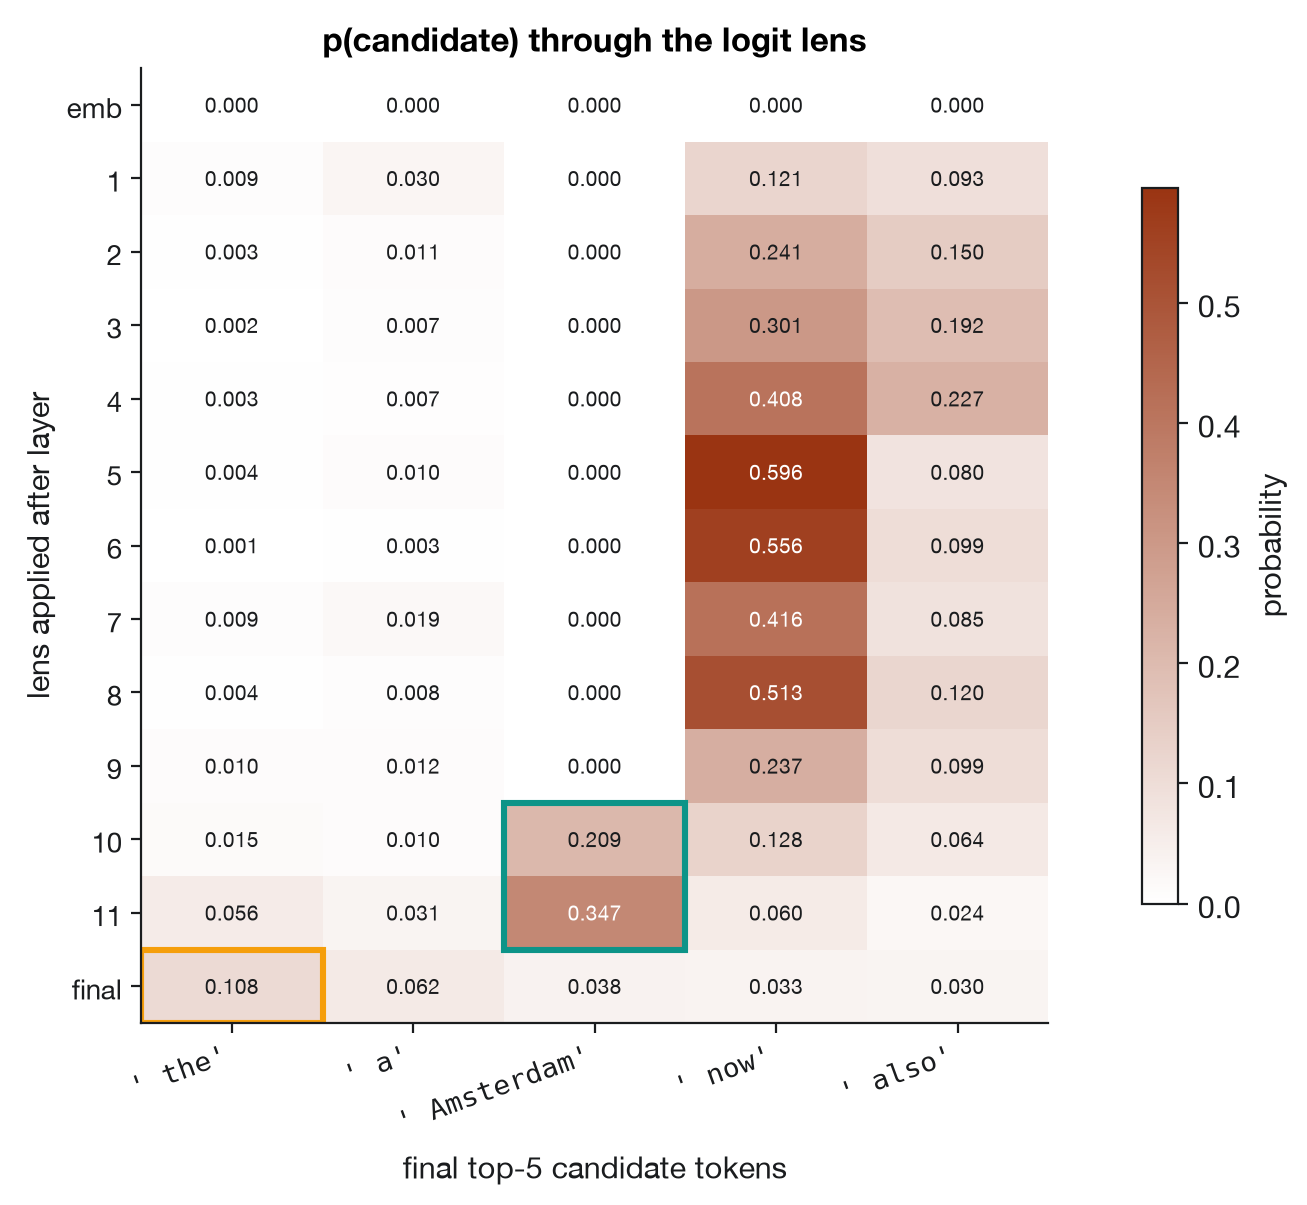

In [10]:
#| label: fig-logit-lens
#| fig-cap: "Logit lens on GPT-2: ' Amsterdam' leads at layers 10-11 (teal), but the final layer hedges back to ' the' (amber). Retrieval and output are different computations."
#| fig-alt: "Grid of the top logit-lens token per layer for a Dutch-capital prompt: Amsterdam surfaces and leads at layers 10 and 11, but the final layer hedges back to a function word."
cand_ids = [int(i) for i in final_top5]
cand_labels = ["'" + tok.decode([i]) + "'" for i in cand_ids]
M = P[:, cand_ids].numpy()

fig, ax = plt.subplots(figsize=(7.6, 6.2))
im = ax.imshow(M, cmap=rust_cmap, vmin=0, vmax=M.max(), aspect="auto")
ax.set_xticks(range(len(cand_labels)))
ax.set_xticklabels(cand_labels, fontsize=10, family="monospace", rotation=20, ha="right")
ax.set_yticks(range(13))
ax.set_yticklabels(["emb"] + [str(i) for i in range(1, 12)] + ["final"], fontsize=10)
ax.set_xlabel("final top-5 candidate tokens")
ax.set_ylabel("lens applied after layer")
for r in range(M.shape[0]):
    for c in range(M.shape[1]):
        ax.text(c, r, f"{M[r, c]:.3f}", ha="center", va="center", fontsize=7.5,
                color="white" if M[r, c] > 0.55 * M.max() else INK)
ams_col = cand_ids.index(ams_id)
ax.add_patch(Rectangle((ams_col - 0.5, ams_first - 0.5), 1, 2, fill=False, edgecolor=TEAL, linewidth=2.2))
ax.add_patch(Rectangle((-0.5, 11.5), 1, 1, fill=False, edgecolor=AMBER, linewidth=2.2))
ax.set_title("p(candidate) through the logit lens")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.75, pad=0.08, label="probability")
plt.show()

## 5. The residual stream grows as it flows

Why did unembedding intermediate layers require that LayerNorm? Because the residual stream is not scale-stable: every block *adds* its output to the stream, and the sum swells. We measure the L2 norm of the hidden state at each layer (mean over the prompt's tokens) for the same prompt.

In [11]:
norms = [float(h[0].norm(dim=-1).mean()) for h in out_ll.hidden_states]
print("mean L2 norm per layer:", [round(n, 1) for n in norms])
print(f"growth emb -> block 11: {norms[0]:.1f} -> {norms[11]:.0f} ({norms[11] / norms[0]:.0f}x); "
      f"after final LayerNorm: {norms[12]:.0f}")

mean L2 norm per layer: [6.2, 69.9, 153.8, 479.1, 514.6, 544.7, 565.3, 584.0, 601.8, 623.5, 648.8, 740.0, 186.0]
growth emb -> block 11: 6.2 -> 740 (119x); after final LayerNorm: 186


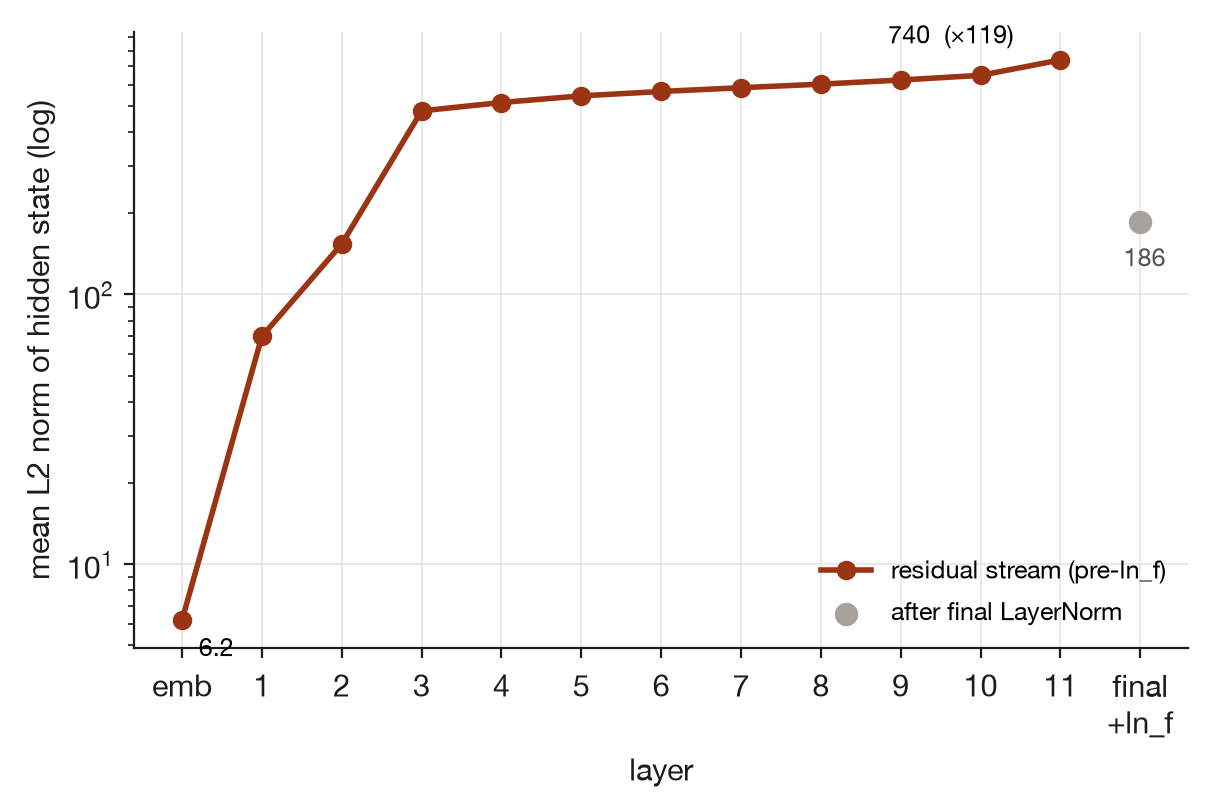

In [12]:
#| label: fig-residual-norms
#| fig-cap: "L2 norm of GPT-2's residual stream per layer (log scale): a ~119x swell from embeddings to block 11, collapsed by the final LayerNorm. Early- and late-layer interventions operate at different scales."
#| fig-alt: "Line plot of residual-stream L2 norm per GPT-2 layer on a log scale: norms swell roughly 119-fold from the embeddings to block 11, then collapse at the final layer norm."
fig, ax = plt.subplots(figsize=(6.8, 4))
ax.plot(range(12), norms[:12], color=RUST, marker="o", linewidth=2, zorder=3,
        label="residual stream (pre-ln_f)")
ax.scatter([12], [norms[12]], color=STONE, s=55, zorder=3, label="after final LayerNorm")
GRAPHITE = "#57534E"  # secondary text
ax.set_yscale("log")
ax.set_xticks(range(13))
ax.set_xticklabels(["emb"] + [str(i) for i in range(1, 12)] + ["final\n+ln_f"])
ax.set_xlabel("layer")
ax.set_ylabel("mean L2 norm of hidden state (log)")
ax.annotate(f"{norms[0]:.1f}", (0, norms[0]), textcoords="offset points", xytext=(6, -13), fontsize=9)
ax.annotate(f"{norms[11]:.0f}  (\u00d7{norms[11] / norms[0]:.0f})", (11, norms[11]),
            textcoords="offset points", xytext=(-62, 6), fontsize=9)
ax.annotate(f"{norms[12]:.0f}", (12, norms[12]), textcoords="offset points",
            xytext=(-6, -16), fontsize=9, color=GRAPHITE)
ax.legend(loc="lower right", fontsize=9)
plt.show()

A hundredfold swell from embeddings to the last block. Honestly read, it is front-loaded: blocks 1-3 alone multiply the norm 77x (from 6.2 to 479), with a single 3.1x jump at block 3, while blocks 4-11 together add only ~1.5x more. This is why explanation methods cannot treat layers interchangeably: a fixed-size steering vector added at layer 2 is a shout, at layer 11 a whisper; gradient magnitudes (Chapter 4) and probe accuracies (Chapter 6) shift with depth partly for this boring geometric reason; and any method that compares or edits hidden states across layers must normalize first, which is exactly what `ln_f` did for our lens.

## 6. The model-artifacts inventory

Everything this chapter touched is an *artifact*: something the model exposes that an explanation method can consume. This table is the chapter's takeaway and the book's table of contents in disguise: each row is a family of methods, and the access column tells you what remains possible when the model sits behind an API.

| Artifact | What it is (as touched here) | Access needed | Who taps it |
|---|---|---|---|
| **Weights** | the embedding matrix we probed for neighbors; all learned parameters | full white-box (files on disk) | this ch.; Ch. 10 (circuits), Ch. 12 (training-time) |
| **Attention maps** | per-head mixing weights (layer 5, head 10) | white-box forward pass | Ch. 5 (visualization and its limits) |
| **Hidden states** | 13 residual-stream snapshots; the logit lens's raw material | white-box forward pass | this ch.; Ch. 6 (probes, concepts), Ch. 10 (SAEs, patching) |
| **Logits / probabilities** | per-layer and final next-token distributions | gray-box (some APIs expose top-k logprobs) | Ch. 4 (perturbation attribution), Ch. 8-9 (calibration, faithfulness) |
| **Samples** | generated text only | black-box (any chat window) | Ch. 8-9 (self-explanations), Ch. 11 (behavioral audits), Ch. 13 |

Rule of thumb: every step down this table is a step *out* in access and a step *down* in what you can verify. Chapter 2's taxonomy called this the invasiveness ladder; you have now touched every rung on a real model.

## Now try it on your own data

The logit lens is a general instrument: point it at any prompt. Find your own **convergence layer**: the first layer where the lens agrees with the model's final answer. Facts the model knows well surface in the last third (our ` Amsterdam` appeared at layer 10 of 12); pure syntax converges earlier; things the model does not know never converge; the lens just drifts. Try to find one prompt of each kind.

In [13]:
# TODO 1: replace with your own prompt (works best when one specific token should follow)
MY_PROMPT = "The Eiffel Tower is located in the city of"

out_my, lens_my = logit_lens(MY_PROMPT)            # reuses the helper from section 4
p_my = lens_my.softmax(-1)
answer_id = int(lens_my[-1].argmax())
print(f"model's final answer: {tok.decode([answer_id])!r}\n")
for layer in range(lens_my.shape[0]):
    top1 = int(lens_my[layer].argmax())
    marker = "  <-- lens agrees with final answer" if top1 == answer_id else ""
    print(f"layer {layer:>2}: lens top-1 = {tok.decode([top1])!r:>14}  "
          f"p(final answer) = {float(p_my[layer, answer_id]):.3f}{marker}")

# TODO 2: compute the convergence layer programmatically (first layer where the marker fires)
# TODO 3: try (a) a fact the model plausibly does NOT know (GPT-2's training data ends in 2019),
#         (b) a purely syntactic prompt such as "She picked up the keys and locked the" , 
#         where does each converge, if at all?
# TODO 4 (stretch): re-plot section 5's norm curve for your prompt. Does the growth pattern
#         change with the prompt? Why would you expect it not to?

model's final answer: ' Paris'

layer  0: lens top-1 =      ' destro'  p(final answer) = 0.000
layer  1: lens top-1 =         ' the'  p(final answer) = 0.000
layer  2: lens top-1 =         ' the'  p(final answer) = 0.000
layer  3: lens top-1 =         ' the'  p(final answer) = 0.000
layer  4: lens top-1 =         ' the'  p(final answer) = 0.000
layer  5: lens top-1 =         ' the'  p(final answer) = 0.000
layer  6: lens top-1 =     ' England'  p(final answer) = 0.000
layer  7: lens top-1 =        ' East'  p(final answer) = 0.001
layer  8: lens top-1 =         ' Ing'  p(final answer) = 0.001
layer  9: lens top-1 =        ' Rome'  p(final answer) = 0.015
layer 10: lens top-1 =      ' London'  p(final answer) = 0.194
layer 11: lens top-1 =       ' Paris'  p(final answer) = 0.165  <-- lens agrees with final answer
layer 12: lens top-1 =       ' Paris'  p(final answer) = 0.064  <-- lens agrees with final answer
